# Predictive Maintenance using Machine Learning

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to understand the AI4I 2020 Predictive Maintenance dataset before building any machine learning models.

Exploratory Data Analysis helps identify data quality issues, understand feature distributions, analyze relationships between variables, and generate insights that guide feature engineering and model development.

---

## Dataset

**AI4I 2020 Predictive Maintenance Dataset**

The dataset contains sensor readings collected from industrial machines along with machine failure information. The goal is to predict whether a machine is likely to fail based on its operating conditions.

---

## Tasks Performed

- Load and inspect the dataset
- Check data types and summary statistics
- Identify missing values and duplicate records
- Analyze class imbalance
- Visualize feature distributions
- Explore correlations between variables
- Study relationships between machine failures and operating conditions
- Identify opportunities for feature engineering

---

## Outcome

The insights obtained from this notebook will be used to:

- Design meaningful engineered features
- Select appropriate machine learning models
- Build a robust preprocessing pipeline
- Improve predictive performance while avoiding data leakage

In [3]:
import sys
print(sys.executable)

C:\Users\Utkar\anaconda3\envs\Predictive-Maintenance-Anomaly-Detection\python.exe


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
os.getcwd()

'C:\\Shruti\\ML-Projects\\Anomaly-Detection\\Predictive-Maintenance-Anomaly-Detection\\notebooks'

In [55]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [56]:
df.shape

(10000, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [12]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

## Distribution of Target Variable - Machine Failure

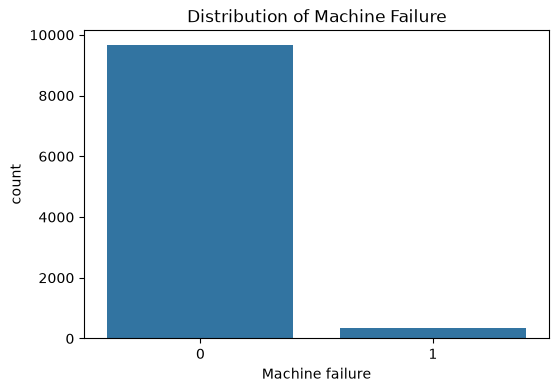

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Distribution of Machine Failure")

plt.show()

## Observation

### What did I observe?

- The target variable is highly imbalanced.
- Only about 3.4% of observations correspond to machine failures.

### Why is this important?

- Machine failures are rare events in real manufacturing environments.
- This supports the choice of anomaly detection over a standard classification-first approach.

### Impact on modeling

- We will not balance the data for Isolation Forest because it is an unsupervised algorithm.
- The imbalance will be considered during model evaluation.

## Distribution of Machine Types

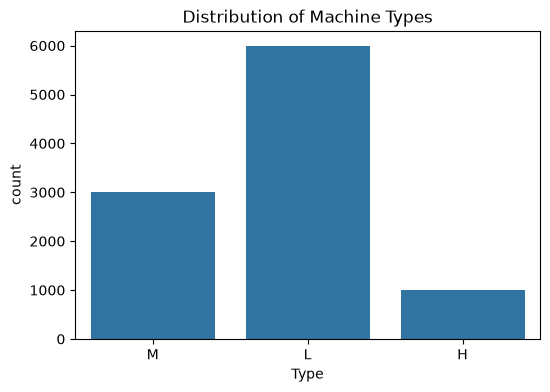

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Type")

plt.title("Distribution of Machine Types")

plt.show()

## Observation

### What did I observe?

- Machine Type L is the most common (~60%).
- Machine Type M represents ~30%.
- Machine Type H is the least common (~10%).

### Why is this important?

- The distribution reflects a realistic manufacturing setup where different machine types may be produced or used in different quantities.
- Simply comparing the number of failures across machine types could be misleading because the group sizes are different.

### Impact on modeling

- Later, we'll compare **failure rates** rather than absolute failure counts across machine types.
- The `Type` feature may carry predictive information and should be encoded before modeling.

## Bi-variate Analysis

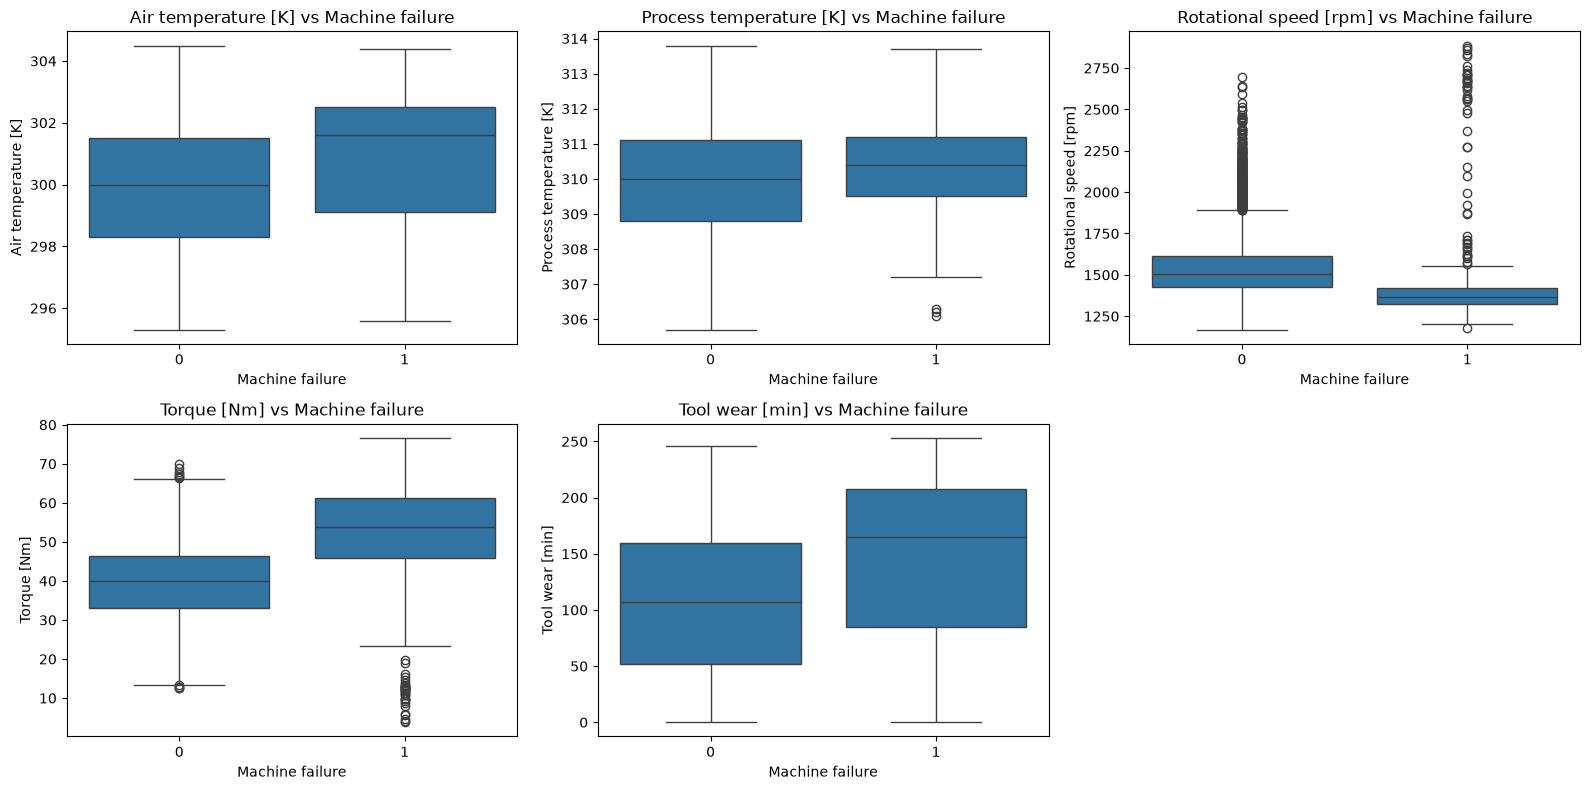

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target = 'Machine failure'

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x=target,
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} vs {target}')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Overall Observations

1. Failed machines generally operate at higher air temperature, process temperature, torque, and tool wear.
2. Failed machines tend to have lower rotational speed.
3. Torque and rotational speed show the strongest visual separation between failed and normal machines.
4. Individual features overlap considerably, suggesting that no single feature alone can identify failures.
5. The combination of multiple sensor measurements is likely to provide better predictive power than any individual feature.
6. Several apparent outliers are present, but they should not be removed without investigation because they may represent genuine anomalous machine behavior.

## Correlation Heatmap

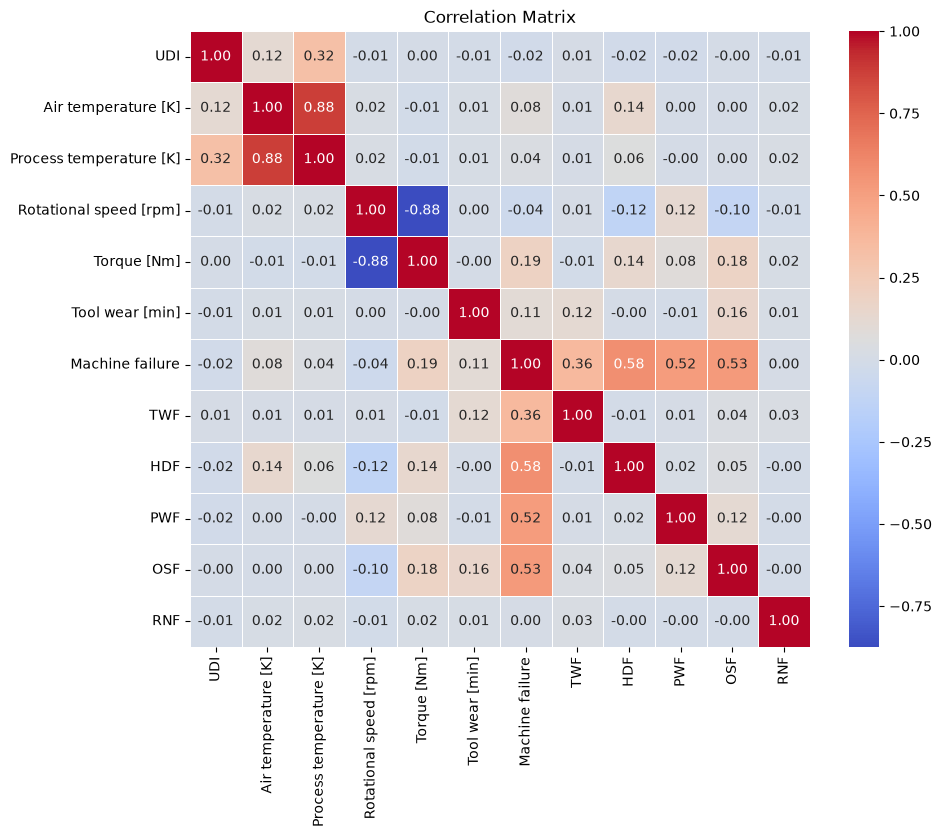

In [27]:
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

## Observations

### What did I observe?

1. Air Temperature and Process Temperature show a strong positive correlation (0.88), indicating they tend to increase together.
2. Rotational Speed and Torque show a strong negative correlation (-0.88), suggesting an inverse relationship.
3. Individual sensor features have relatively weak linear correlations with Machine Failure.
4. Failure mode columns (TWF, HDF, PWF, OSF) are highly correlated with Machine Failure because they describe specific failure types.

### Business Insight

- Sensor readings are interconnected and reflect machine operating conditions.
- Machine failure is likely influenced by multiple sensor measurements rather than any single variable.
- Different failure modes contribute to overall machine failure.

### Modeling Impact

- Keep Air Temperature and Process Temperature despite high correlation because they represent different physical measurements and Isolation Forest is not highly sensitive to multicollinearity.
- Exclude TWF, HDF, PWF, OSF, and RNF from the model to avoid data leakage.
- Use the sensor measurements and machine type as input features.

In [28]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_counts = df[failure_modes].sum().sort_values(ascending=False)

failure_counts

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

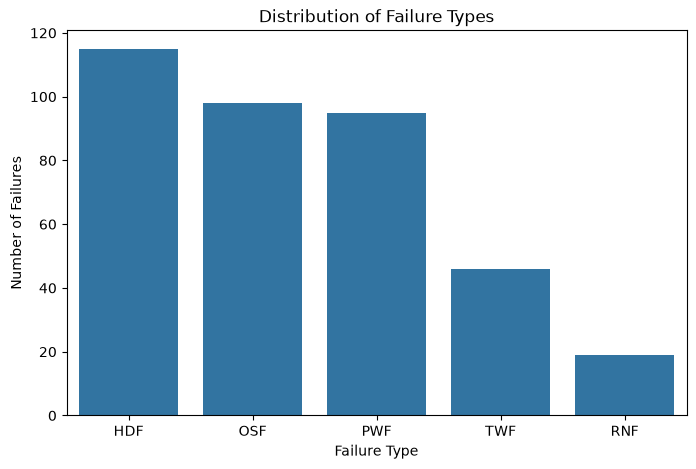

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=failure_counts.index,
    y=failure_counts.values
)

plt.title("Distribution of Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Number of Failures")

plt.show()

## Observations

### What did I observe?

- Heat Dissipation Failure (HDF) is the most frequent failure type.
- Random Failure (RNF) is the least frequent failure type.
- Failure modes are themselves highly imbalanced.

### Business Insight

- Engineers may prioritize reducing the most common failure mechanism since it contributes to a larger proportion of machine failures.
- Rare failure modes may require specialized investigation because they occur infrequently but could still be critical.

### Modeling Impact

- These columns will **not** be used as input features because they represent failure outcomes and would introduce data leakage.
- They are useful for post-model analysis to understand which failure mechanisms are detected by the anomaly detection model.

# Exploratory Data Analysis Summary

## Dataset Quality
- No missing values
- No duplicate records
- Correct data types

## Target Variable
- Highly imbalanced (~3.4% failures)

## Feature Analysis
- Machine Type L dominates the dataset.
- Torque and Rotational Speed show stronger visual separation.
- Individual sensor variables overlap considerably.

## Correlation Analysis
- Air Temperature and Process Temperature are highly positively correlated (0.88).
- Rotational Speed and Torque are highly negatively correlated (-0.88).
- Individual sensor variables have relatively weak linear correlations with Machine Failure.

## Failure Mode Analysis
- Most common failure type: HDF
- Least common failure type: RNF
- Failure modes are useful for business understanding but will not be used as model inputs because they would introduce data leakage.

## -------------------------------------------------------------------------------------------------------------------------------------------------

# Feature Engineering

Feature engineering is the process of creating new features from existing data to better represent the underlying patterns in the dataset.

The objective is to improve the model's ability to distinguish between normal and abnormal machine behavior by incorporating domain knowledge.

Rather than creating numerous arbitrary features, only hypothesis-driven features based on exploratory data analysis and engineering intuition are created.

## Temperature Difference

The difference between Process Temperature and Air Temperature represents the excess heat generated by the machine during operation.

A higher temperature difference may indicate inefficient heat dissipation or abnormal operating conditions, making it a potentially useful feature for anomaly detection.

In [32]:
df["Temperature_Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

## Mechanical Load

Mechanical load is approximated by multiplying Torque and Rotational Speed.

Machines operating under both high torque and high rotational speed experience greater mechanical stress, which may increase the likelihood of abnormal behavior.

In [33]:
df["Mechanical_Load"] = (
    df["Torque [Nm]"] *
    df["Rotational speed [rpm]"]
)

## Wear Stress

Tool wear and torque together represent the stress experienced by a worn tool.

As a tool becomes worn, higher torque requirements may indicate increasing resistance and potential mechanical degradation.

In [34]:
df["Wear_Stress"] = (
    df["Tool wear [min]"] *
    df["Torque [Nm]"]
)

## Wear Heat

Tool wear combined with process temperature captures the interaction between mechanical wear and thermal conditions.

A worn tool operating at high temperatures may be more susceptible to failure than either factor alone.

In [35]:
df["Wear_Heat"] = (
    df["Tool wear [min]"] *
    df["Process temperature [K]"]
)

In [36]:
new_features = [
    "Temperature_Difference",
    "Mechanical_Load",
    "Wear_Stress",
    "Wear_Heat"
]

df[new_features].head()

,Temperature_Difference,Mechanical_Load,Wear_Stress,Wear_Heat
0,10.5,66382.8,0.0,0.0
1,10.5,65190.4,138.9,926.1
2,10.4,74001.2,247.0,1542.5
3,10.4,56603.5,276.5,2160.2
4,10.5,56320.0,360.0,2778.3


In [37]:
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature_Difference,10000.0,10.00063,1.001094,7.6,9.30,9.80,11.000,12.1
Mechanical_Load,10000.0,59967.14704,10193.093881,10966.8,53105.40,59883.90,66873.750,99980.4
Wear_Stress,10000.0,4314.66455,2826.567692,0.0,1963.65,4012.95,6279.000,16497.0
Wear_Heat,10000.0,33466.68392,19736.918760,0.0,16408.80,33426.80,50354.475,79011.9


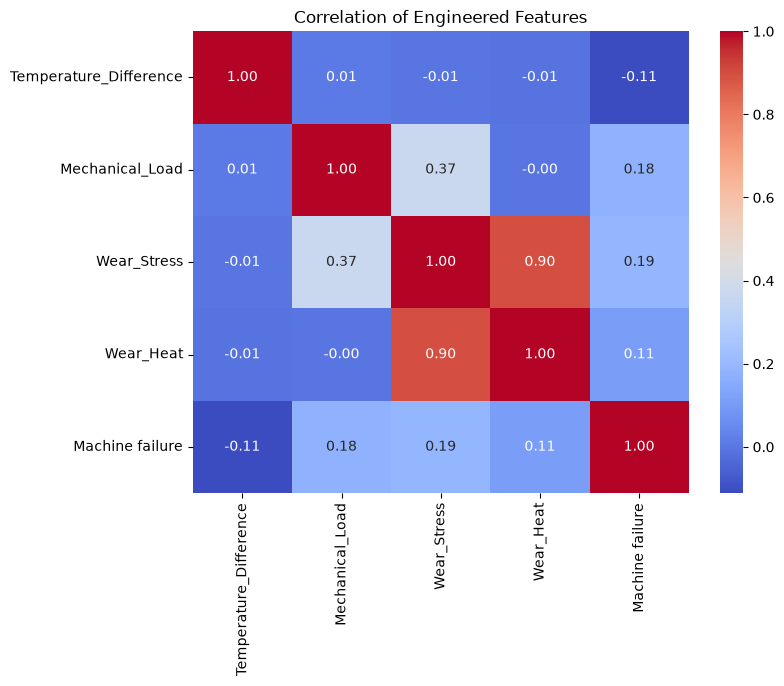

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[new_features + ["Machine failure"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Engineered Features")
plt.show()

## Summary

Four domain-driven features were engineered:

- Temperature Difference
- Mechanical Load
- Wear Stress
- Wear Heat

These features were created based on insights obtained during exploratory data analysis and engineering intuition.

The original features were retained because they still contain independent information. The usefulness of the engineered features will be validated during model evaluation.

In [42]:
df.to_csv("../data/processed/featured_data.csv", index=False)